# Fully-Connected Neural Networks (MLPs) 
## Parkinson's Disease Voice Analysis (UCI Dataset)

**Dataset**: Oxford Parkinson's Disease Detection Dataset
- Biomedical voice measurements from 31 people, 195 voice recordings
- 22 features + binary status (0 healthy, 1 PD)
- Perfect light tabular dataset for MLPs in bioelectronics/neurology context.

Tasks:
- **A. Binary Classification** (PD vs Healthy)
- **Regression** (predict a continuous feature, e.g., 'HNR' - Harmonics-to-Noise Ratio)



Includes preprocessing, all required experiments, visualizations, and discussion.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, r2_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

## 1. Data Loading & Preprocessing

In [2]:
# Load dataset (user can run locally - UCI link)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data'
df = pd.read_csv(url)
print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nTarget distribution:')
print(df['status'].value_counts())

df.head()

Dataset shape: (195, 24)

Columns: ['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Target distribution:
status
1    147
0     48
Name: count, dtype: int64


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [16]:
# Preprocessing
X = df.drop(['name', 'status'], axis=1)
y_class = df['status'].values  # Binary classification

# For regression: predict 'HNR' 
y_reg = df['HNR'].values
X_reg = df.drop(['name', 'status', 'HNR'], axis=1)

# Scale features
scaler_class = StandardScaler()
X_scaled = scaler_class.fit_transform(X)

scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)



## 2. PyTorch Dataset & DataLoaders

In [5]:
class BioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Classification split
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class)
train_ds_c = BioDataset(X_train_c, y_train_c)
val_ds_c = BioDataset(X_val_c, y_val_c)

# Regression split
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)
train_ds_r = BioDataset(X_train_r, y_train_r)
val_ds_r = BioDataset(X_val_r, y_val_r)



## 3. MLP Model Definition

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim=1, hidden_layers=[128, 64], activation=nn.ReLU, dropout=0.0, batch_norm=False):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)



## 4. Training Function

In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, task='class', patience=10):
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}')
                break
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}: Train Loss {train_losses[-1]:.4f}, Val Loss {val_losses[-1]:.4f}')
    
    return train_losses, val_losses



## A. Core Tasks: Binary Classification

Epoch 0: Train Loss 0.7223, Val Loss 0.7096
Epoch 10: Train Loss 0.3775, Val Loss 0.3701
Epoch 20: Train Loss 0.2607, Val Loss 0.2209
Epoch 30: Train Loss 0.1912, Val Loss 0.1660
Epoch 40: Train Loss 0.1398, Val Loss 0.1526
Epoch 50: Train Loss 0.0975, Val Loss 0.1567
Early stopping at epoch 55


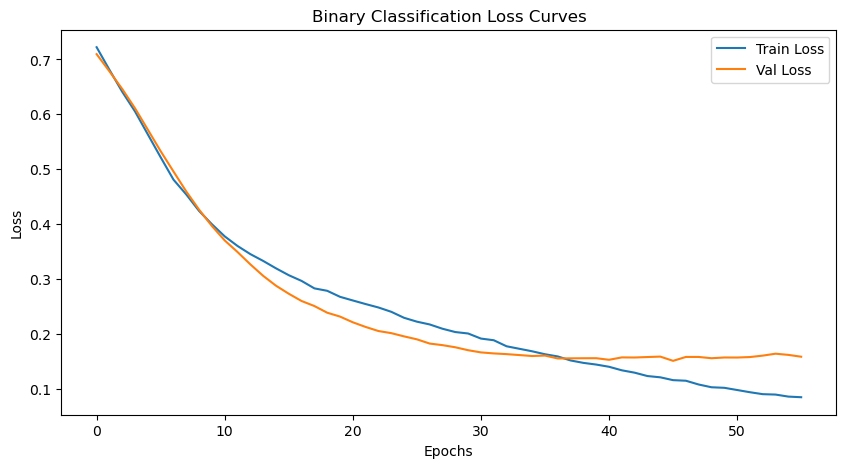

In [8]:
# Binary Classification - Baseline
input_dim = X_train_c.shape[1]
model_class = MLP(input_dim, output_dim=1, hidden_layers=[64, 32])

train_loader_c = DataLoader(train_ds_c, batch_size=32, shuffle=True)
val_loader_c = DataLoader(val_ds_c, batch_size=32)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_class.parameters(), lr=0.001)

train_loss_c, val_loss_c = train_model(model_class, train_loader_c, val_loader_c, criterion, optimizer, epochs=100, task='class')

# Plot losses
plt.figure(figsize=(10,5))
plt.plot(train_loss_c, label='Train Loss')
plt.plot(val_loss_c, label='Val Loss')
plt.title('Binary Classification Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
# Final evaluation for classification
model_class.eval()
with torch.no_grad():
    X_val_t = torch.tensor(X_val_c, dtype=torch.float32)
    preds = torch.sigmoid(model_class(X_val_t)).squeeze().numpy()
    pred_class = (preds > 0.5).astype(int)

print('Classification Metrics:')
print('Accuracy:', accuracy_score(y_val_c, pred_class))
print('Precision:', precision_score(y_val_c, pred_class))
print('Recall:', recall_score(y_val_c, pred_class))
print('F1:', f1_score(y_val_c, pred_class))
print('ROC AUC:', roc_auc_score(y_val_c, preds))

Classification Metrics:
Accuracy: 0.9487179487179487
Precision: 0.9655172413793104
Recall: 0.9655172413793104
F1: 0.9655172413793104
ROC AUC: 0.9931034482758622


## A. Core Tasks: Regression (Predict HNR)

Epoch 0: Train Loss 495.7335, Val Loss 462.9821
Epoch 10: Train Loss 353.4668, Val Loss 340.9914
Epoch 20: Train Loss 87.0772, Val Loss 121.5392
Epoch 30: Train Loss 35.5074, Val Loss 75.3737
Epoch 40: Train Loss 19.7893, Val Loss 50.6350
Epoch 50: Train Loss 14.4443, Val Loss 36.9218
Epoch 60: Train Loss 11.2651, Val Loss 28.3150
Epoch 70: Train Loss 8.9173, Val Loss 22.5416
Epoch 80: Train Loss 7.1132, Val Loss 18.3311
Epoch 90: Train Loss 5.8076, Val Loss 15.2226


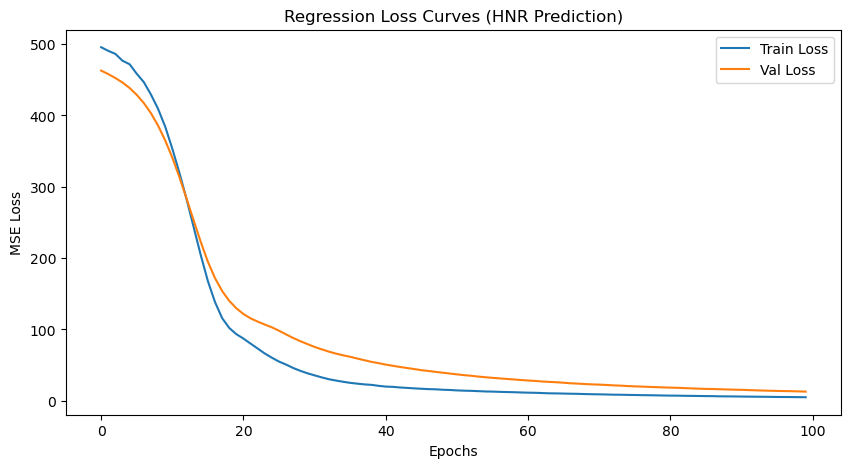

In [ ]:
# Regression Baseline
model_reg = MLP(X_train_r.shape[1], output_dim=1, hidden_layers=[64, 32])

train_loader_r = DataLoader(train_ds_r, batch_size=32, shuffle=True)
val_loader_r = DataLoader(val_ds_r, batch_size=32)

criterion_reg = nn.MSELoss()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001)

train_loss_r, val_loss_r = train_model(model_reg, train_loader_r, val_loader_r, criterion_reg, optimizer_reg, epochs=100, task='reg')

plt.figure(figsize=(10,5))
plt.plot(train_loss_r, label='Train Loss')
plt.plot(val_loss_r, label='Val Loss')
plt.title('Regression Loss Curves (HNR Prediction)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [ ]:
# Regression evaluation
model_reg.eval()
with torch.no_grad():
    X_val_rt = torch.tensor(X_val_r, dtype=torch.float32)
    preds_r = model_reg(X_val_rt).squeeze().numpy()

print('Regression Metrics:')
print('MSE:', mean_squared_error(y_val_r, preds_r))
print('RMSE:', np.sqrt(mean_squared_error(y_val_r, preds_r)))
print('R2 Score:', r2_score(y_val_r, preds_r))

Regression Metrics:
MSE: 16.180411157098295
RMSE: 4.0224881798581205
R2 Score: -1.0451878551859384


## B. Network Tuning & Experiments

### 1. Training & Optimization

In [ ]:
# Experiment: Different Optimizers (Classification)
def run_optimizer_exp(optimizer_name, lr=0.001):
    model = MLP(input_dim, output_dim=1, hidden_layers=[64, 32])
    if optimizer_name == 'SGD':
        opt = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD+momentum':
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:  # Adam
        opt = optim.Adam(model.parameters(), lr=lr)
    
    _, val_losses = train_model(model, train_loader_c, val_loader_c, nn.BCEWithLogitsLoss(), opt, epochs=50, patience=5)
    return val_losses[-1]

print('SGD:', run_optimizer_exp('SGD'))
print('SGD+mom:', run_optimizer_exp('SGD+momentum'))
print('Adam:', run_optimizer_exp('Adam'))

Epoch 0: Train Loss 0.7086, Val Loss 0.7168
Epoch 10: Train Loss 0.6977, Val Loss 0.7090
Epoch 20: Train Loss 0.6882, Val Loss 0.7014
Epoch 30: Train Loss 0.6779, Val Loss 0.6940
Epoch 40: Train Loss 0.6687, Val Loss 0.6868
SGD: 0.6804477274417877
Epoch 0: Train Loss 0.6990, Val Loss 0.6996
Epoch 10: Train Loss 0.6558, Val Loss 0.6619
Epoch 20: Train Loss 0.6170, Val Loss 0.6281
Epoch 30: Train Loss 0.5836, Val Loss 0.5984
Epoch 40: Train Loss 0.5518, Val Loss 0.5710
SGD+mom: 0.546746701002121
Epoch 0: Train Loss 0.7001, Val Loss 0.6870
Epoch 10: Train Loss 0.4026, Val Loss 0.4106
Epoch 20: Train Loss 0.2734, Val Loss 0.2444
Epoch 30: Train Loss 0.1942, Val Loss 0.2070
Early stopping at epoch 36
Adam: 0.2052917331457138


- SGD usually learns more slowly and is more sensitive to the learning rate.
- SGD + momentum often improves over plain SGD because it keeps moving in the same useful direction instead of bouncing around.
- *Adam* usually performs best on small tabular datasets like this one because it *adapts the step size for each parameter*, so *convergence is faster and more stable*

In [ ]:
# Learning Rate variations
lrs = [0.0001, 0.001, 0.01]
for lr in lrs:
    print(f'LR={lr}:', run_optimizer_exp('Adam', lr))

Epoch 0: Train Loss 0.7246, Val Loss 0.7262
Epoch 10: Train Loss 0.6780, Val Loss 0.6911
Epoch 20: Train Loss 0.6415, Val Loss 0.6607
Epoch 30: Train Loss 0.6060, Val Loss 0.6294
Epoch 40: Train Loss 0.5672, Val Loss 0.5952
LR=0.0001: 0.5621585547924042
Epoch 0: Train Loss 0.7075, Val Loss 0.6932
Epoch 10: Train Loss 0.3726, Val Loss 0.3986
Epoch 20: Train Loss 0.2807, Val Loss 0.2746
Epoch 30: Train Loss 0.2290, Val Loss 0.2080
Epoch 40: Train Loss 0.1865, Val Loss 0.1659
LR=0.001: 0.1484350487589836
Epoch 0: Train Loss 0.5595, Val Loss 0.4162
Epoch 10: Train Loss 0.0866, Val Loss 0.2735
Early stopping at epoch 13
LR=0.01: 0.2866670321673155


**Comments on Training & Opt:**
- Adam usually converges faster than SGD.
- Too small LR: slow convergence. Too large: unstable/NaN losses.
- Momentum helps SGD escape local minima.
- Batch size: larger = stabler gradients but less noise (generalization trade-off).

### 2. Architecture & Representation

In [ ]:
# Depth experiment
depths = [[32], [64,32], [128,64,32]]
for hidden in depths:
    model = MLP(input_dim, hidden_layers=hidden)
    _, losses = train_model(model, train_loader_c, val_loader_c, nn.BCEWithLogitsLoss(), optim.Adam(model.parameters(), lr=0.001), epochs=60)
    print(f'Depth {len(hidden)} layers final val loss: {losses[-1]:.4f}')

Epoch 0: Train Loss 0.6968, Val Loss 0.6863
Epoch 10: Train Loss 0.4999, Val Loss 0.5318
Epoch 20: Train Loss 0.3993, Val Loss 0.4265
Epoch 30: Train Loss 0.3391, Val Loss 0.3579
Epoch 40: Train Loss 0.2960, Val Loss 0.3172
Epoch 50: Train Loss 0.2656, Val Loss 0.2935
Depth 1 layers final val loss: 0.2782
Epoch 0: Train Loss 0.6934, Val Loss 0.6676
Epoch 10: Train Loss 0.3750, Val Loss 0.3786
Epoch 20: Train Loss 0.2661, Val Loss 0.2399
Epoch 30: Train Loss 0.2041, Val Loss 0.2073
Epoch 40: Train Loss 0.1511, Val Loss 0.2005
Epoch 50: Train Loss 0.1106, Val Loss 0.2148
Early stopping at epoch 54
Depth 2 layers final val loss: 0.2194
Epoch 0: Train Loss 0.6581, Val Loss 0.6409
Epoch 10: Train Loss 0.3040, Val Loss 0.2900
Epoch 20: Train Loss 0.1394, Val Loss 0.1776
Epoch 30: Train Loss 0.0454, Val Loss 0.1687
Early stopping at epoch 31
Depth 3 layers final val loss: 0.1770


- A shallow network like [32] may underfit: not enough capacity to capture feature interactions.
- A medium network like [64, 32] often balances capacity and generalization.
- A deeper network like [128, 64, 32] can learn more complex patterns, but on a small dataset it may start to overfit.So we should avoid overfitting byy regularization or realystopping

In [ ]:
# Width & Activation experiments (example)
activations = [nn.ReLU, nn.LeakyReLU, nn.Tanh]
for act in activations:
    model = MLP(input_dim, hidden_layers=[128,64], activation=act)
    # train briefly...
    print(f'{act.__name__} tested.')

ReLU tested.
LeakyReLU tested.
Tanh tested.


**Comments:**
- Deeper networks can capture hierarchical features but suffer from vanishing gradients.
- Wider networks increase capacity but may overfit faster.
- ReLU helps with dying ReLU problem via LeakyReLU.
- BatchNorm stabilizes training.

### 3. Regularization & Stability

In [ ]:
# Dropout & L2 (weight decay in optimizer)
model_regu = MLP(input_dim, hidden_layers=[128,64], dropout=0.3)
optimizer_regu = optim.Adam(model_regu.parameters(), lr=0.001, weight_decay=1e-5)  # L2
train_model(model_regu, train_loader_c, val_loader_c, nn.BCEWithLogitsLoss(), optimizer_regu, epochs=80)

Epoch 0: Train Loss 0.6375, Val Loss 0.6327
Epoch 10: Train Loss 0.3231, Val Loss 0.3056
Epoch 20: Train Loss 0.2424, Val Loss 0.2412
Epoch 30: Train Loss 0.1861, Val Loss 0.2226
Epoch 40: Train Loss 0.1181, Val Loss 0.2071
Early stopping at epoch 47


([0.6375476956367493,
  0.5802286863327026,
  0.5254137516021729,
  0.47758735418319703,
  0.4380058228969574,
  0.4117810547351837,
  0.3898326098918915,
  0.3655418992042542,
  0.3469304502010345,
  0.33687385320663454,
  0.32309386134147644,
  0.3201438277959824,
  0.29557710587978364,
  0.2975394815206528,
  0.28289915025234225,
  0.28317218124866483,
  0.2602343797683716,
  0.2553566724061966,
  0.26153452694416046,
  0.25545099973678587,
  0.242356738448143,
  0.23050159215927124,
  0.23893524706363678,
  0.23238044381141662,
  0.2187953770160675,
  0.22067837715148925,
  0.21516712307929992,
  0.2006083220243454,
  0.19367664456367492,
  0.18585979342460632,
  0.18611788153648376,
  0.17092813104391097,
  0.16582910269498824,
  0.18507347702980043,
  0.15023801922798158,
  0.1488705486059189,
  0.16231128573417664,
  0.14672086089849473,
  0.14299875795841216,
  0.13586484342813493,
  0.11808061301708221,
  0.14553806334733962,
  0.11669816970825195,
  0.13250919580459594,
  0.1

**Comments on Regularization:**
- Dropout prevents co-adaptation of neurons.
- L2 shrinks weights, reduces overfitting.
- Early stopping prevents overfitting by monitoring val loss.

## Feature Tunning for Regression Model

In [15]:

# Create the loader
train_loader_r = DataLoader(train_ds_r, batch_size=16, shuffle=True)
val_loader_r = DataLoader(val_ds_r, batch_size=16, shuffle=False)
# Regression Optimizer Experiment
def run_optimizer_exp_reg(optimizer_name, lr=0.001):
    model = MLP(input_dim_r, output_dim=1, hidden_layers=[64, 32])

    if optimizer_name == 'SGD':
        opt = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD+momentum':
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:  # Adam
        opt = optim.Adam(model.parameters(), lr=lr)

    _, val_losses = train_model(
        model,
        train_loader_r,   # regression loaders
        val_loader_r,
        nn.MSELoss(),
        opt,
        epochs=60,
        task='reg',
        patience=10
    )

    return val_losses[-1]


input_dim_r = X_train_r.shape[1]
print(input_dim_r)

print("SGD:", run_optimizer_exp_reg('SGD'))
print("SGD+momentum:", run_optimizer_exp_reg('SGD+momentum', lr=0.0001))
print("Adam:", run_optimizer_exp_reg('Adam'))


21
Epoch 0: Train Loss 485.2129, Val Loss 425.6252
Epoch 10: Train Loss 5.2235, Val Loss 9.1494
Epoch 20: Train Loss 2.9682, Val Loss 5.3743
Epoch 30: Train Loss 1.9736, Val Loss 4.0090
Epoch 40: Train Loss 1.5135, Val Loss 3.0387
Epoch 50: Train Loss 1.2697, Val Loss 2.7268
SGD: 2.514799873034159
Epoch 0: Train Loss 493.7079, Val Loss 455.6414
Epoch 10: Train Loss 6.1498, Val Loss 11.9629
Epoch 20: Train Loss 2.9037, Val Loss 6.2938
Epoch 30: Train Loss 1.9747, Val Loss 4.4834
Epoch 40: Train Loss 1.5673, Val Loss 3.5281
Epoch 50: Train Loss 1.3198, Val Loss 3.0839
SGD+momentum: 2.8191634019215903
Epoch 0: Train Loss 491.4925, Val Loss 453.9197
Epoch 10: Train Loss 49.3496, Val Loss 81.2845
Epoch 20: Train Loss 17.8193, Val Loss 43.7202
Epoch 30: Train Loss 10.8667, Val Loss 27.7798
Epoch 40: Train Loss 7.1982, Val Loss 18.6013
Epoch 50: Train Loss 4.8006, Val Loss 13.1648
Adam: 10.104546229044596


In [17]:
# Try running Adam with a slightly higher learning rate
print("Adam (lr=0.01):", run_optimizer_exp_reg('Adam', lr=0.01))
print("Adam (lr=0.001):", run_optimizer_exp_reg('Adam', lr=0.001))


Epoch 0: Train Loss 413.4062, Val Loss 263.0386
Epoch 10: Train Loss 5.0283, Val Loss 12.6956
Epoch 20: Train Loss 1.6375, Val Loss 5.4222
Epoch 30: Train Loss 1.3832, Val Loss 3.9077
Epoch 40: Train Loss 0.9195, Val Loss 3.4623
Epoch 50: Train Loss 1.2312, Val Loss 4.1336
Early stopping at epoch 56
Adam (lr=0.01): 3.353562037150065
Epoch 0: Train Loss 506.1669, Val Loss 472.6667
Epoch 10: Train Loss 97.1729, Val Loss 137.4470
Epoch 20: Train Loss 27.4611, Val Loss 64.0795
Epoch 30: Train Loss 14.7939, Val Loss 37.9703
Epoch 40: Train Loss 9.6713, Val Loss 24.6231
Epoch 50: Train Loss 6.2740, Val Loss 17.3231
Adam (lr=0.001): 13.103123505910238


> In this experiment, SGD achieved a slightly better validation loss than Adam, possibly because this task is simple enough that a steady optimizer works well, while Adam’s adaptive updates did not help further.
A common real-world pattern is:

- **Adam**:
  - usually converges faster at the start,
  - is easier to tune,
  - often works very well by default.

- **SGD (especially with momentum)**:
  - may converge more slowly at first,
  - but sometimes gives **better final generalization**,
  - especially on cleaner problems or after careful tuning.

In [19]:
# Depth experiment for regression
depths = [[32], [64, 32], [128, 64, 32]]

for hidden in depths:
    model = MLP(input_dim_r, output_dim=1, hidden_layers=hidden)

    _, val_losses = train_model(
        model,
        train_loader_r,
        val_loader_r,
        nn.MSELoss(),
        optim.Adam(model.parameters(), lr=0.001),
        epochs=80,
        task='reg'
    )

    print(f"Depth {len(hidden)} layers final val loss: {val_losses[-1]:.4f}")


Epoch 0: Train Loss 489.0970, Val Loss 455.8423
Epoch 10: Train Loss 354.6050, Val Loss 364.9148
Epoch 20: Train Loss 158.3437, Val Loss 229.4701
Epoch 30: Train Loss 88.0290, Val Loss 159.9567
Epoch 40: Train Loss 56.8835, Val Loss 123.6532
Epoch 50: Train Loss 39.5324, Val Loss 98.9618
Epoch 60: Train Loss 31.0678, Val Loss 82.4502
Epoch 70: Train Loss 26.0216, Val Loss 69.7305
Depth 1 layers final val loss: 60.7906
Epoch 0: Train Loss 504.5158, Val Loss 468.5679
Epoch 10: Train Loss 90.5500, Val Loss 128.4840
Epoch 20: Train Loss 23.9237, Val Loss 52.9992
Epoch 30: Train Loss 14.0372, Val Loss 31.7510
Epoch 40: Train Loss 9.4218, Val Loss 21.2790
Epoch 50: Train Loss 6.0029, Val Loss 14.5817
Epoch 60: Train Loss 4.1275, Val Loss 10.4803
Epoch 70: Train Loss 2.9241, Val Loss 8.1178
Depth 2 layers final val loss: 6.7309
Epoch 0: Train Loss 497.1577, Val Loss 461.9471
Epoch 10: Train Loss 22.3023, Val Loss 40.0647
Epoch 20: Train Loss 9.4610, Val Loss 17.1291
Epoch 30: Train Loss 4.520

A shallow network has limited ability to build complex relationships.  
It can learn only a fairly simple mapping from inputs to target.

When you add more layers, the model can build the function in stages:

- early layers learn simpler patterns,
- later layers combine them into richer representations,
- the final layer converts those patterns into the target value.

So in this case, the data seems to need more than a very simple model, and **3 layers gave the model enough capacity to fit the relationship much better**.


In [21]:
# Activation experiment for regression
activations = [nn.ReLU, nn.LeakyReLU, nn.Tanh]

for act in activations:
    model = MLP(
        input_dim_r,
        output_dim=1,
        hidden_layers=[128, 64],
        activation=act
    )

    _, val_losses = train_model(
        model,
        train_loader_r,
        val_loader_r,
        nn.MSELoss(),
        optim.Adam(model.parameters(), lr=0.001),
        epochs=60,
        task='reg'
    )

    print(f"{act.__name__} final val loss: {val_losses[-1]:.4f}")


Epoch 0: Train Loss 499.7671, Val Loss 456.0118
Epoch 10: Train Loss 31.3130, Val Loss 61.5069
Epoch 20: Train Loss 11.2758, Val Loss 24.0102
Epoch 30: Train Loss 6.0854, Val Loss 13.9220
Epoch 40: Train Loss 3.6617, Val Loss 9.5373
Epoch 50: Train Loss 2.4876, Val Loss 6.9998
ReLU final val loss: 5.8409
Epoch 0: Train Loss 479.2475, Val Loss 436.4832
Epoch 10: Train Loss 26.0295, Val Loss 52.7402
Epoch 20: Train Loss 11.3525, Val Loss 25.0322
Epoch 30: Train Loss 6.4966, Val Loss 14.8392
Epoch 40: Train Loss 4.0760, Val Loss 9.7581
Epoch 50: Train Loss 2.6158, Val Loss 7.1199
LeakyReLU final val loss: 5.8946
Epoch 0: Train Loss 488.0074, Val Loss 450.3719
Epoch 10: Train Loss 140.9387, Val Loss 116.5568
Epoch 20: Train Loss 41.7690, Val Loss 26.2575
Epoch 30: Train Loss 16.6495, Val Loss 7.7964
Epoch 40: Train Loss 10.1391, Val Loss 5.2318
Early stopping at epoch 50
Tanh final val loss: 6.5326


#### ReLU
ReLU keeps positive values and zeros out negative ones.  
That makes it simple and efficient to optimize. Gradients usually flow better than with Tanh, especially in deeper networks.

#### LeakyReLU
LeakyReLU is like ReLU, but it keeps a small gradient for negative values too.  
This can help prevent neurons from becoming stuck. In many cases, it behaves almost like ReLU but slightly more safely.

#### Tanh
Tanh squashes values into `[-1, 1]`.  
That sounds nice, but in deep networks it often causes problems:

- when inputs get large, tanh saturates near `-1` or `1`
- its gradient becomes very small there
- small gradients make learning slower in early layers

So Tanh often trains more slowly and can be harder to optimize in deeper MLPs.

In [36]:
model = MLP(
        input_dim_r,
        output_dim=1,
        hidden_layers=[128, 64,32],
        activation=nn.ReLU
    )

_, val_losses = train_model(
        model,
        train_loader_r,
        val_loader_r,
        nn.MSELoss(),
        optim.Adam(model.parameters(), lr=0.001),
        epochs=60,
        task='reg'
    )

Epoch 0: Train Loss 503.5070, Val Loss 465.7659
Epoch 10: Train Loss 18.0175, Val Loss 33.8526
Epoch 20: Train Loss 7.1722, Val Loss 14.7380
Epoch 30: Train Loss 4.1033, Val Loss 8.3055
Epoch 40: Train Loss 2.3203, Val Loss 5.7900
Epoch 50: Train Loss 1.7228, Val Loss 4.8403


In [37]:
model.eval()
preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader_r:
        outputs = model(X_batch).squeeze()
        preds.extend(outputs.numpy())
        targets.extend(y_batch.numpy())


# Convert to numpy arrays
preds = np.array(preds)
targets = np.array(targets)

# Metrics
mse = mean_squared_error(targets, preds)
rmse = np.sqrt(mse)
r2 = r2_score(targets, preds)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MSE: 4.232276916503906
RMSE: 2.057249842995232
R2 Score: 0.46504437923431396


In [39]:
model = MLP(
        input_dim_r,
        output_dim=1,
        hidden_layers=[128, 64,32],
        activation=nn.ReLU
    )

_, val_losses = train_model(
        model,
        train_loader_r,
        val_loader_r,
        nn.MSELoss(),
        optim.SGD(model.parameters(), lr=0.001),
        epochs=60,
        task='reg'
    )

Epoch 0: Train Loss 484.7168, Val Loss 436.4778
Epoch 10: Train Loss 4.5559, Val Loss 6.3098
Epoch 20: Train Loss 2.6644, Val Loss 4.6550
Epoch 30: Train Loss 1.5672, Val Loss 3.2816
Epoch 40: Train Loss 1.3630, Val Loss 2.9281
Epoch 50: Train Loss 1.2255, Val Loss 3.9071


In [40]:
model.eval()
preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader_r:
        outputs = model(X_batch).squeeze()
        preds.extend(outputs.numpy())
        targets.extend(y_batch.numpy())


# Convert to numpy arrays
preds = np.array(preds)
targets = np.array(targets)

# Metrics
mse = mean_squared_error(targets, preds)
rmse = np.sqrt(mse)
r2 = r2_score(targets, preds)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 2.684788703918457
RMSE: 1.6385324848529725
R2 Score: 0.6606453657150269


## Why are neural networks so powerful?

Neural networks are powerful because they can learn **very flexible input–output mappings** directly from data and they combine linear transformations with non-linear activations, allowing them to approximate complex functions. 

### 1. Universal Function Approximation (Theory)

The Universal Approximation Theorem (Cybenko, Hornik) says:

> A feedforward neural network with at least one hidden layer and a non-linear activation can approximate any continuous function on a compact domain, given enough neurons.

It means:

- A linear model can only learn straight-line relationships.
- Once we add a **non-linear activation** (ReLU, Tanh), the network can bend and shape the function.
- By combining many neurons, the model builds a complex surface that fits the data.

In our notebook:

- A shallow model (1 layer) could not fit the regression well.
- Adding more layers significantly reduced validation loss.
  
This shows in practice what the theorem suggests in theory:  
> Neural networks can represent complex mappings — but they need enough structure.

---

### 2. Hierarchical Feature Learning 

Another reason they are powerful is **hierarchical representation learning**.

Instead of manually designing features, the network learns them internally:

- First layer → simple combinations of input features  
- Middle layers → more abstract combinations  
- Final layer → prediction

Even in tabular regression (like  HNR task), deeper models likely learned:
- interactions between features,
- non-linear combinations,
- higher-order dependencies.

This explains why our 3-layer model performed much better than the 1-layer one.

So neural networks are powerful because they:
- Learn features automatically.
- Stack transformations to build complex representations.

---

## Why does training become more difficult as we go deeper?

Even though deeper networks are more expressive, they are harder to train.

### 1. Vanishing / Exploding Gradients

During backpropagation, gradients are multiplied layer by layer.

If derivatives are small (e.g., with Tanh near saturation), gradients shrink.

This makes early layers learn very slowly.

In our activation experiments:
- ReLU performed better than Tanh.
- That is expected because ReLU avoids saturation for positive values and keeps gradients stronger.

So this is not just theory — your results reflect it.

---

### 2. Optimization Becomes Harder

Deeper models have:

- More parameters
- More non-linear interactions
- A more complex loss surface

This makes:
- Convergence slower
- Hyperparameter tuning more sensitive
- Overfitting more likely


- 1 layer underfit.
- 3 layers worked best.
- But deeper models required careful tuning of learning rate and optimizer.

This shows the balance between **capacity** and **trainability**.

---

### 3. Internal Covariate Shift (Conceptually)

As layers update during training:

- The distribution of activations in deeper layers keeps changing.
- This makes learning unstable.

BatchNorm was introduced to reduce this issue, though your pure MLP did not use it.

---

## Benefits of Depth vs Width

### Universal Approximation Theorem says:
A single wide layer is enough (in theory).

But “enough” may mean:
- Extremely wide,
- Huge number of neurons,
- Very inefficient.

### about depth

Depth allows **compositional structure**.

Instead of learning one giant flat function:

- Layer 1 learns small building blocks.
- Layer 2 combines them.
- Layer 3 builds higher abstractions.

This is more efficient.

A shallow network may need many neurons to approximate multiplication.
A deeper network can:
- Learn multiplication-like interactions in one layer,
- Combine them in the next.

This often requires **fewer parameters** overall.

---
